# Spotify User Churn Model

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,precision_score,recall_score,f1_score
import time 


### EDA

In [25]:
df = pd.read_csv('/Users/jiyamaheshwari/Downloads/churn_data.csv')

In [26]:
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [27]:
df.describe(include = 'all')

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
count,50000.000000,50000,50000.000000,50000,50000,50000,50000.000000,50000.000000,50000,50000,50000.000000,50000.000000,50000,50000,50000,50000,50000.000000,50000.000000
unique,NaN,12,NaN,2982,5,2,NaN,NaN,2,2,NaN,NaN,12,8,6,5,NaN,NaN
top,NaN,India,NaN,2026-01-18,Free,Active,NaN,NaN,No,No,NaN,NaN,Classical,Lyrics,Mood-based Auto Playlists,Smart Speaker,NaN,NaN
freq,NaN,4265,NaN,33,22525,42109,NaN,NaN,32514,45648,NaN,NaN,4272,6358,8419,10050,NaN,NaN
mean,25000.500000,NaN,38.010280,NaN,NaN,NaN,1.533020,0.222460,NaN,NaN,3.644100,9.988986,NaN,NaN,NaN,NaN,8.002680,10.025920
std,14433.901067,NaN,12.984989,NaN,NaN,NaN,1.952082,0.415903,NaN,NaN,1.114424,3.968927,NaN,NaN,NaN,NaN,2.831571,3.165579
min,1.000000,NaN,16.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,1.000000
25%,12500.750000,NaN,27.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,3.000000,7.280000,NaN,NaN,NaN,NaN,6.000000,8.000000
50%,25000.500000,NaN,38.000000,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,4.000000,9.980000,NaN,NaN,NaN,NaN,8.000000,10.000000
75%,37500.250000,NaN,49.000000,NaN,NaN,NaN,2.000000,0.000000,NaN,NaN,5.000000,12.680000,NaN,NaN,NaN,NaN,10.000000,12.000000


In [28]:
df = df.drop(columns=['user_id','signup_date'])

In [29]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
df[binary_cols] = df[binary_cols].replace({'Active': 1, 'Inactive': 0,
                                           'Yes': 1, 'No': 0})

In [30]:
multi_cat_cols = [col for col in df.columns if df[col].nunique() > 2 and ((df[col].dtype == 'object') or (df[col].dtype == 'string'))]
df = pd.get_dummies(df, columns=multi_cat_cols,drop_first=True)

In [31]:
df.head()

,age,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Indonesia,country_Italy,country_Mexico,country_Spain,country_UK,country_USA,subscription_type_Premium Duo,subscription_type_Premium Family,subscription_type_Premium Individual,subscription_type_Student,favorite_genre_Classical,favorite_genre_Country,favorite_genre_Electronic,favorite_genre_Hip-Hop,favorite_genre_Indie,favorite_genre_Jazz,favorite_genre_K-Pop,favorite_genre_Latin,favorite_genre_Pop,favorite_genre_R&B,favorite_genre_Rock,most_liked_feature_Daily Mix,most_liked_feature_Discover Weekly,most_liked_feature_Lyrics,most_liked_feature_Offline Mode,most_liked_feature_Playlists,most_liked_feature_Podcasts,most_liked_feature_Radio,desired_future_feature_Concert Alerts,desired_future_feature_HiFi Audio,desired_future_feature_Lyrics Translation,desired_future_feature_Mood-based Auto Playlists,desired_future_feature_Social Listening,primary_device_Desktop,primary_device_Mobile,primary_device_Smart Speaker,primary_device_Tablet
0,25,1,0,0,0,0,4,10.13,7,8,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True
1,20,1,0,0,1,0,5,11.63,7,6,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False
2,53,1,0,0,1,1,3,9.50,6,5,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
3,48,1,1,0,0,0,4,13.16,11,8,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False
4,18,1,0,0,0,0,4,12.70,10,11,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True


In [32]:
sum(df.dtypes == str)

0

In [33]:
corr_matrix = df.corr()
churn_corr = corr_matrix[['subscription_status']].sort_values(by='subscription_status', ascending=False)
print(churn_corr)

                                                  subscription_status
subscription_status                                          1.000000
country_USA                                                  0.009210
primary_device_Smart Speaker                                 0.005351
favorite_genre_K-Pop                                         0.004587
favorite_genre_Electronic                                    0.004578
most_liked_feature_Radio                                     0.004255
country_Italy                                                0.004118
music_suggestion_rating_1_to_5                               0.004066
most_liked_feature_Playlists                                 0.003898
desired_future_feature_Concert Alerts                        0.003545
country_Brazil                                               0.003003
primary_device_Tablet                                        0.002952
favorite_genre_R&B                                           0.002450
favorite_genre_Pop  

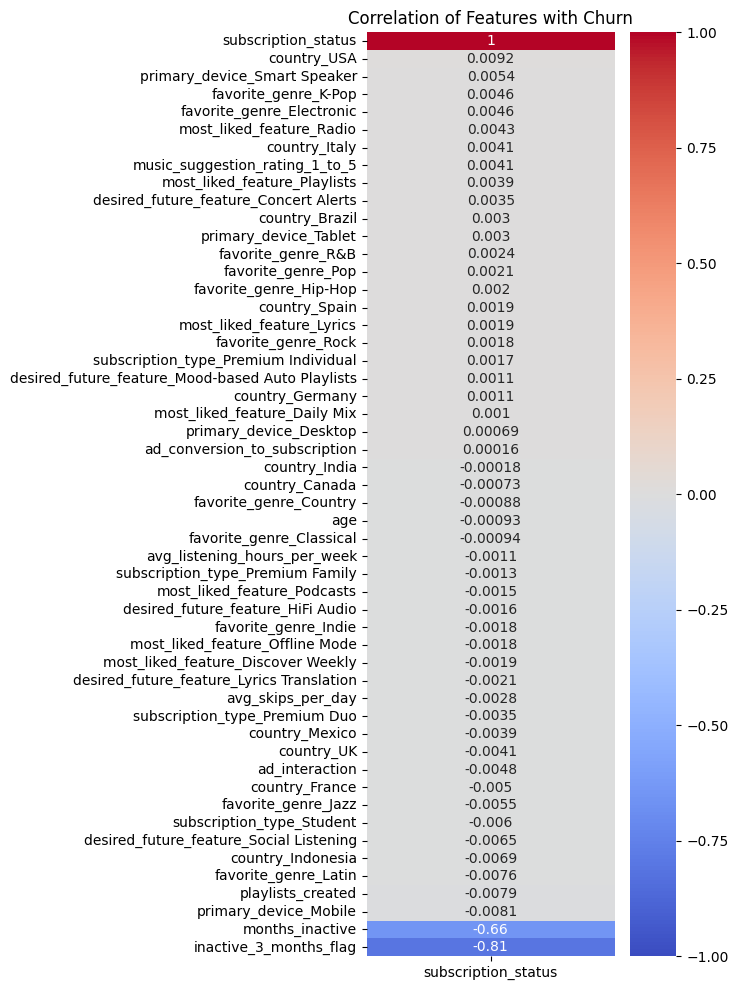

In [34]:
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()

In [35]:
df['subscription_status'].value_counts()

subscription_status
1    42109
0     7891
Name: count, dtype: int64

### ML

In [52]:
X = df.drop(columns=['subscription_status'])
y = df['subscription_status'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
THRESHOLD = 0.3

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',  
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.05,
        num_leaves=31,
        class_weight='balanced',
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=7, 
        random_state=42,
        eval_metric='logloss'
    )
}

In [53]:
rf = models['Random Forest']
rf.fit(X_train, y_train)
y_pred = (rf.predict_proba(X_test)[:, 1] >= THRESHOLD).astype(int)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred,digits=3))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0      0.701     1.000     0.824      1518
           1      1.000     0.924     0.960      8482

    accuracy                          0.935     10000
   macro avg      0.850     0.962     0.892     10000
weighted avg      0.955     0.935     0.940     10000



In [54]:
print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (y_pred >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    1.000   0.924   0.960   
0.3     1.000   0.924   0.960   
0.35    1.000   0.924   0.960   
0.4     1.000   0.924   0.960   
0.45    1.000   0.924   0.960   
0.5     1.000   0.924   0.960   
